## Przykład klasyfikacji cyfr MNIST w PyTorch i śledzenia eksperymentów w MLflow
Notebook pokazuje prosty proces machine learning dla klasyfikacji obrazów cyfr MNIST.
1. Import danych
2. Analiza danych
3. Przygotowanie danych wejściowych
4. Trening modelu
5. Ewaluacja modelu
6. Logowanie wyników w MLflow

In [1]:
from OpenSSL import rand
! pip install mlflow torch torchvision

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
import shutil
from mlflow.models.signature import ModelSignature
from mlflow.types.schema import Schema, TensorSpec
import numpy as np

# SQLite backend instead of deprecated filesystem backend
tracking_db = Path("../model/mlflow.db").resolve()
tracking_db.parent.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{tracking_db}")
mlflow.set_experiment("image_digit_classification_mnist")

input_size = 28 * 28
hidden_size = 100
output_size = 10
learning_rate = 0.001
batch_size = 100
epochs = 5

train_dataset = torchvision.datasets.MNIST(
    root="../data",
    train=True,
    transform=transforms.ToTensor(),
    download=True,
)

test_dataset = torchvision.datasets.MNIST(
    root="../data",
    train=False,
    transform=transforms.ToTensor(),
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
)


class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out


model = NeuralNet(input_size, hidden_size, output_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

run = mlflow.start_run()
mlflow.log_param("input_size", input_size)
mlflow.log_param("hidden_size", hidden_size)
mlflow.log_param("output_size", output_size)
mlflow.log_param("learning_rate", learning_rate)
mlflow.log_param("batch_size", batch_size)
mlflow.log_param("epochs", epochs)

for epoch in range(epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()

        output = model(data.reshape(-1, input_size))
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        step = epoch * len(train_loader) + batch_idx
        mlflow.log_metric("train_loss", loss.item(), step=step)

        if batch_idx % 10 == 0:
            print(f"epoch={epoch + 1}, batch={batch_idx}, loss={loss.item():.4f}")

epoch=1, batch=0, loss=2.2911
epoch=1, batch=10, loss=1.8649
epoch=1, batch=20, loss=1.3996
epoch=1, batch=30, loss=1.0815
epoch=1, batch=40, loss=0.8020
epoch=1, batch=50, loss=0.7365
epoch=1, batch=60, loss=0.5835
epoch=1, batch=70, loss=0.4779
epoch=1, batch=80, loss=0.5457
epoch=1, batch=90, loss=0.3671
epoch=1, batch=100, loss=0.3352
epoch=1, batch=110, loss=0.4586
epoch=1, batch=120, loss=0.4184
epoch=1, batch=130, loss=0.4623
epoch=1, batch=140, loss=0.2768
epoch=1, batch=150, loss=0.3730
epoch=1, batch=160, loss=0.2495
epoch=1, batch=170, loss=0.3780
epoch=1, batch=180, loss=0.3043
epoch=1, batch=190, loss=0.2393
epoch=1, batch=200, loss=0.4254
epoch=1, batch=210, loss=0.3505
epoch=1, batch=220, loss=0.2595
epoch=1, batch=230, loss=0.2849
epoch=1, batch=240, loss=0.3082
epoch=1, batch=250, loss=0.2471
epoch=1, batch=260, loss=0.2814
epoch=1, batch=270, loss=0.2529
epoch=1, batch=280, loss=0.2904
epoch=1, batch=290, loss=0.3663
epoch=1, batch=300, loss=0.3431
epoch=1, batch=310,

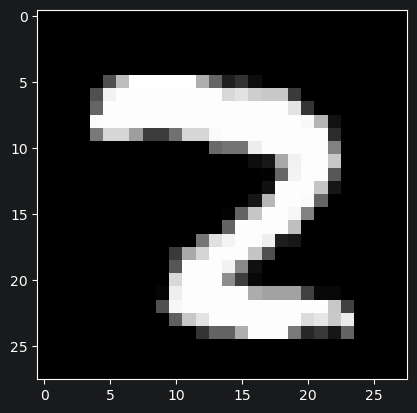

2


<Figure size 640x480 with 0 Axes>

In [3]:
plt.imshow(train_dataset[28][0].reshape(28, 28), cmap='gray')
plt.show()
plt.savefig("number_plot.png")
mlflow.log_artifact("number_plot.png")

print(train_dataset[28][1])


In [4]:
run = mlflow.active_run()
run_id = run.info.run_id

model.eval()

input_example = torch.randn(2, input_size, dtype=torch.float32)

signature = ModelSignature(
    inputs=Schema([
        TensorSpec(np.dtype(np.float32), (-1, input_size))
    ]),
    outputs=Schema([
        TensorSpec(np.dtype(np.float32), (-1, output_size))
    ]),
)

mlflow.pytorch.log_model(
    pytorch_model=model,
    name="mnist_pytorch_model",
    registered_model_name="my_registered_model",
    serialization_format="pt2",
    input_example=input_example,
    signature=signature,
)

local_model_path = Path("../model") / f"my-model-{run_id}"

if local_model_path.exists():
    shutil.rmtree(local_model_path)

mlflow.pytorch.save_model(
    pytorch_model=model,
    path=str(local_model_path),
    serialization_format="pt2",
    input_example=input_example,
    signature=signature,
)

2026/06/18 10:13:14 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpo1b2vxzo/model/data, flavor: pytorch). Fall back to return ['torch==2.12.1', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 
Registered model 'my_registered_model' already exists. Creating a new version of this model...
Created version '4' of model 'my_registered_model'.
2026/06/18 10:13:18 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /home/mzar/mlops-practical-examples/notebooks/model/my-model-cd9b388ab6ff44d1a2401019849dc59d/data, flavor: pytorch). Fall back to return ['torch==2.12.1', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


Accuracy: 0.9687
6 6


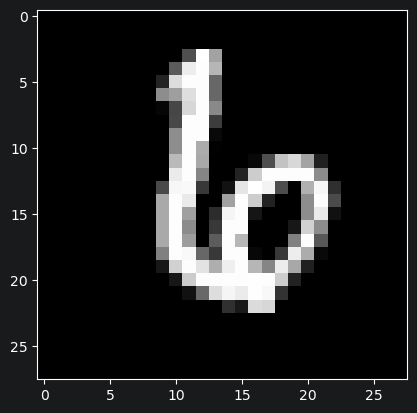

2 2


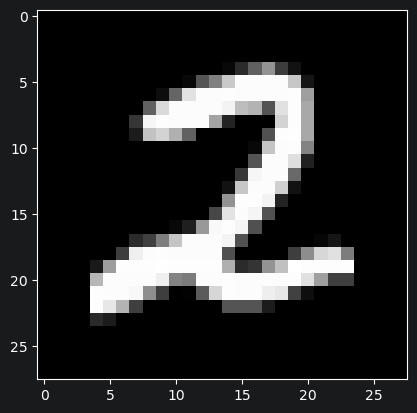

9 9


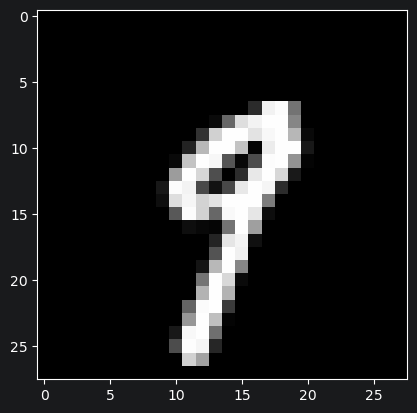

3 3


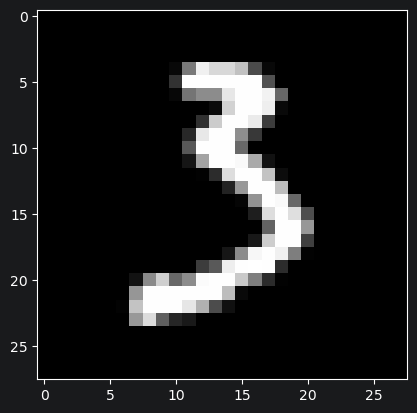

7 7


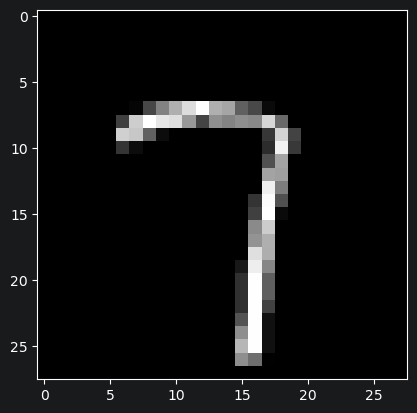

7 7


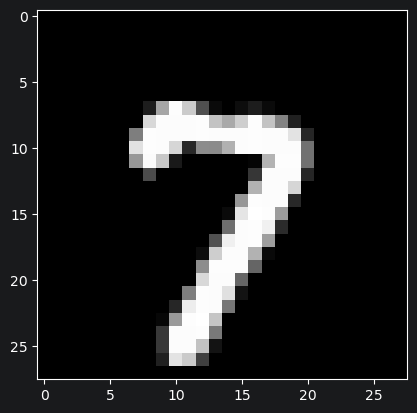

0 0


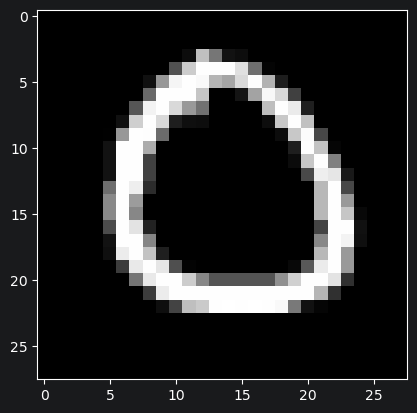

5 5


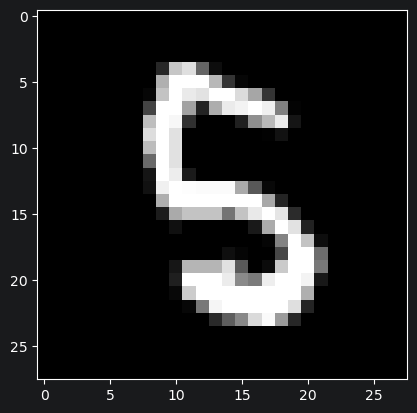

8 8


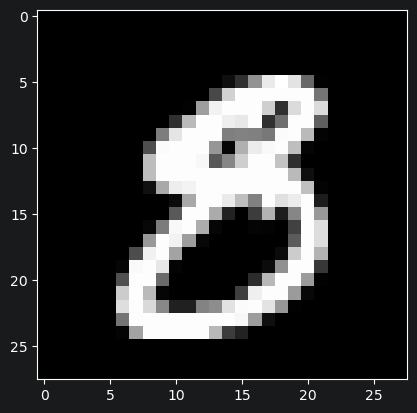

8 8


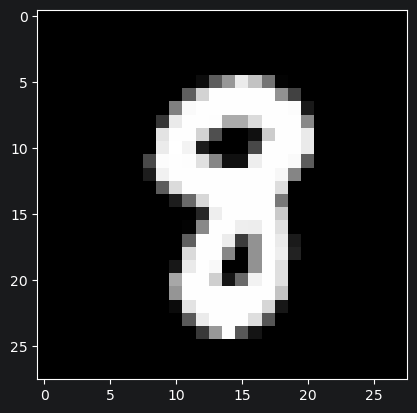

0 0


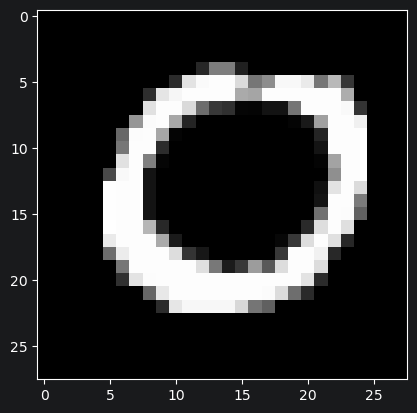

7 7


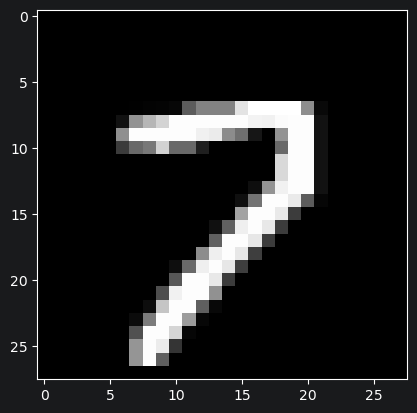

7 7


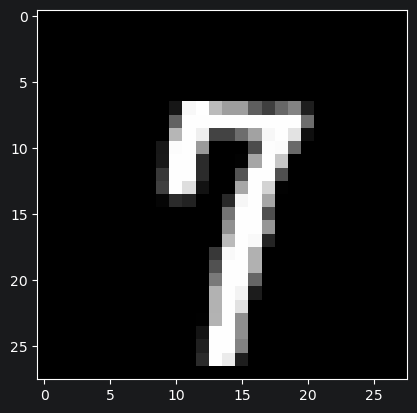

6 5


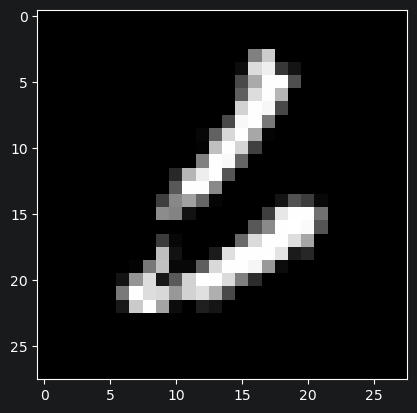

3 3


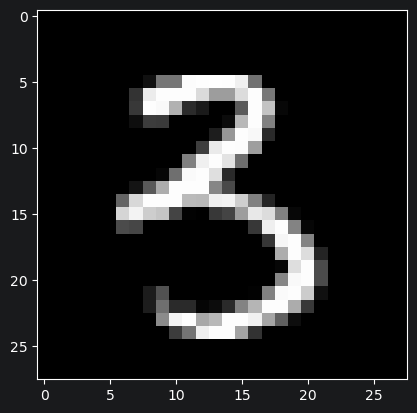

0 0


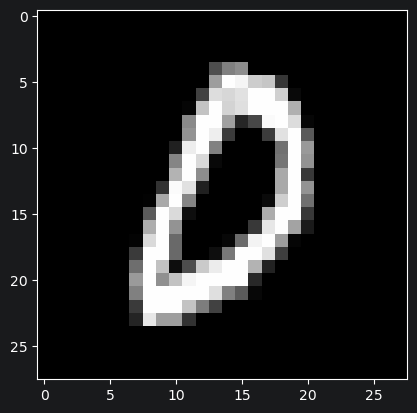

1 1


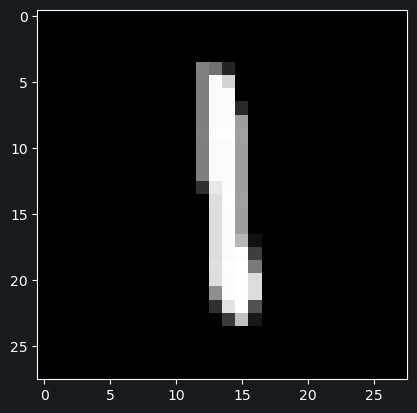

3 3


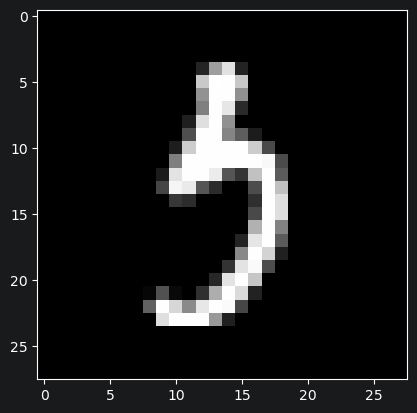

5 5


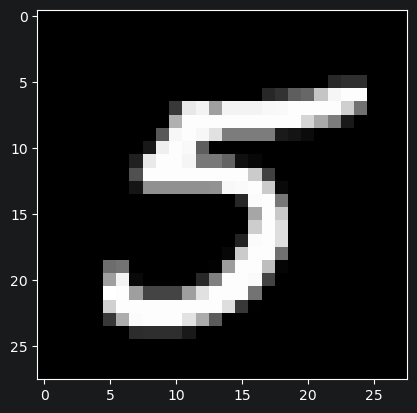

0 0


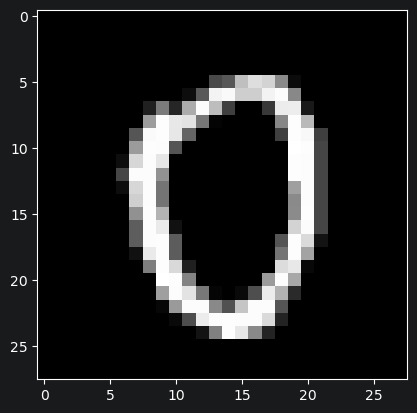

8 8


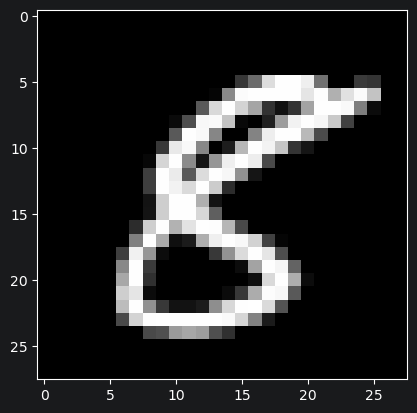

6 6


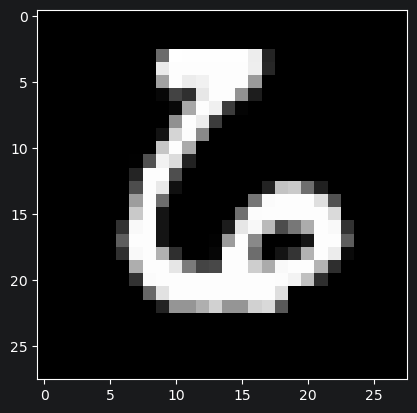

6 6


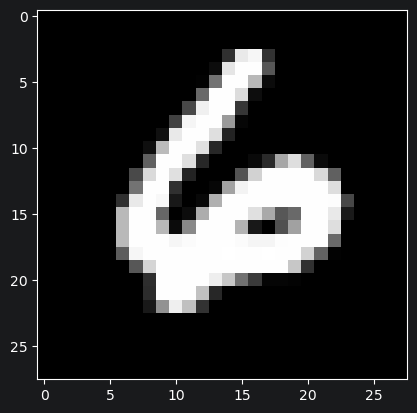

2 2


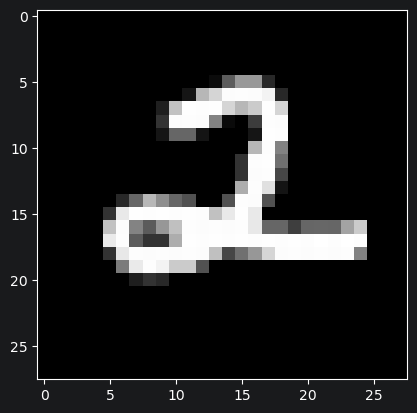

4 4


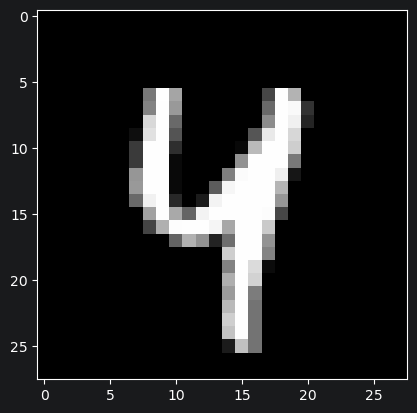

5 5


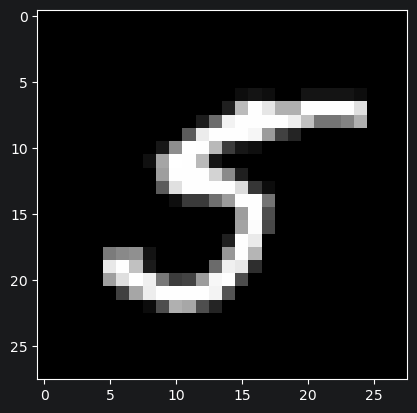

3 3


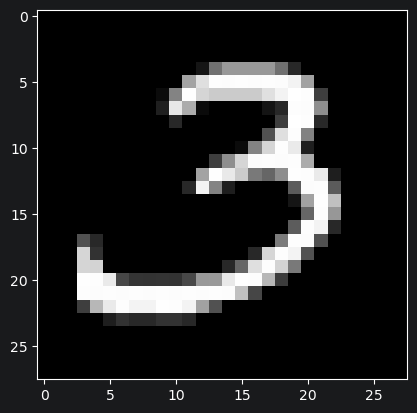

0 0


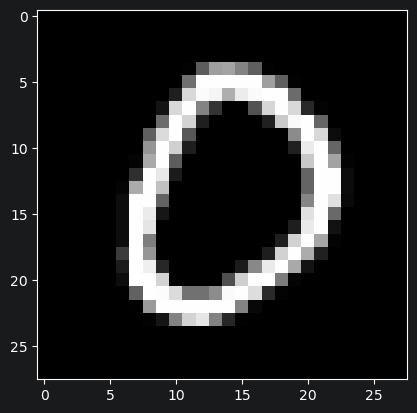

0 0


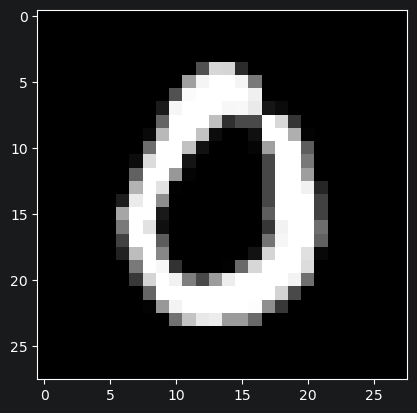

6 6


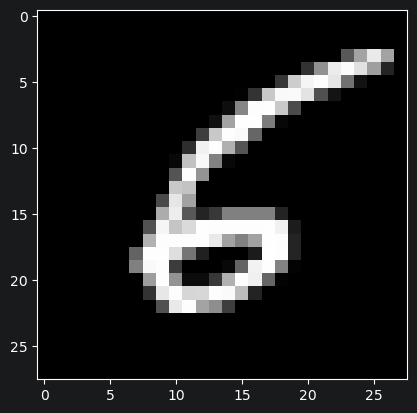

8 8


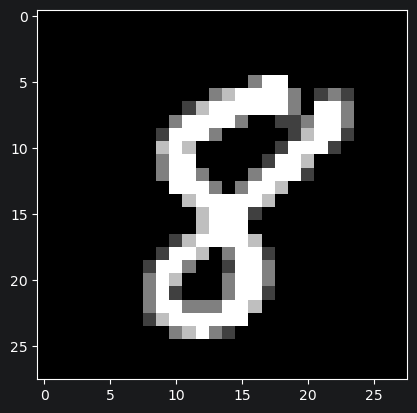

9 9


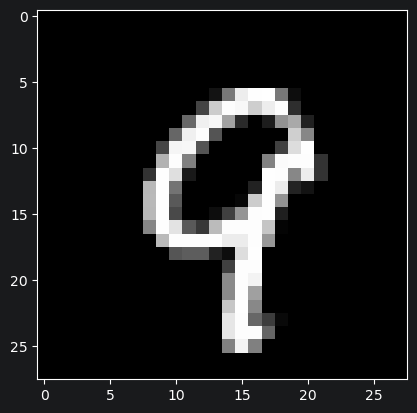

6 6


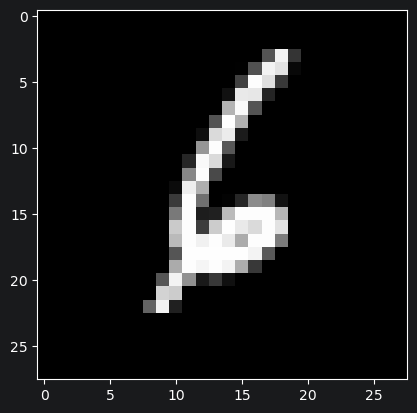

In [5]:
all = 0
correct = 0
for i, (inputs, labels) in enumerate(test_loader):
    predicted = model(inputs.reshape(-1, input_size))
    all += labels.size(0)
    for j, label in enumerate(labels):
        if label.item() == predicted[j].argmax().item():
            correct += 1

print(f'Accuracy: {correct / all}')
mlflow.log_param("test_accuracy", correct / all)
mlflow.end_run()

for i, (inputs, labels) in enumerate(test_loader):
    predicted = model(inputs.reshape(-1, input_size))
    for j, label in enumerate(labels):
        print(label.item(), predicted[j].argmax().item())
        plt.imshow(inputs[j][0], cmap='gray')
        plt.show()
        if j == 10:
            break
    if i == 2:
        break

Uruchom panel UI MLFlow w przeglądarce:

```
mlflow server \
  --backend-store-uri sqlite:///../model/mlflow.db \
  --default-artifact-root ./mlruns \
  --host 127.0.0.1 \
  --port 5000
 ```